<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Deep Learning for Semantic Segmentation</span>

</div>

This notebook implements a **U-Net** model with a **ResNet50 encoder** pre-trained on ImageNet to segment flood‑affected areas from **8‑channel Synthetic Aperture Radar (SAR)** images. The model distinguishes three classes:

- **Non‑Flooded** (background)
- **Flooded Open** (flood water in open areas)
- **Flooded Urban** (flood water in urban zones)

<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**          | **Details**                                    |
|--------------------|------------------------------------------------|
| **Course**         | Deep Learning Project                          |
| **Deliverable**    | <span style="color:#E67E22;">**Deliverable 3 – Model Training & Evaluation**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**   | 28100321 & 28100357                            |

---


In [1]:
!pip install segmentation-models-pytorch albumentations tifffile tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import rasterio
warnings.filterwarnings("ignore")

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 16
num_workers = 4
epochs = 30
lr = 1e-3
imgsize = 256
in_channels = 8
num_classes = 3
path = "/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation"

classes_name = ["Non-Flooded", "Flooded Open", "Flooded Urban"]

## <span style="color:#3498DB;">Dataset Preparation</span>

The **UrbanSARFlood** dataset is used. Each sample consists of an 8‑channel SAR image and a corresponding ground truth mask (3 classes).

### Key steps in UrbanSARDataset:

- Reads .tif files using rasterio.
- Extracts SAR image (8 bands) and mask (single band).
- Applies **per‑channel min‑max normalization**.
- Implements **class balancing** by repeating minority class samples (e.g., 03_FU – Flooded Urban) 4 times.

In [4]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None):
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []
        split_path = os.path.join(dataset_root, split_file)
        if os.path.exists(split_path):
            with open(split_path, "r") as f:
                for line in f.readlines():
                    raw_path = line.strip()
                    if not raw_path:
                        continue
                    path_parts = raw_path.split('/')
                    clean_base_path = os.path.join(*path_parts[-3:])
                    if "GT" in clean_base_path:
                        clean_gt_rel_path = clean_base_path
                        clean_sar_rel_path = clean_base_path.replace("GT", "SAR")
                    else:
                        clean_sar_rel_path = clean_base_path
                        clean_gt_rel_path = clean_base_path.replace("SAR", "GT")
                    sar_full_path = os.path.join(dataset_root, clean_sar_rel_path)
                    gt_full_path = os.path.join(dataset_root, clean_gt_rel_path)
                    num_repeats = 1
                    if "Train" in split_file and "03_FU" in clean_base_path:
                        num_repeats = 4 # We wanted more FU hence we are inflating it
                    for _ in range(num_repeats):
                        self.image_paths.append(sar_full_path)
                        self.mask_paths.append(gt_full_path)
        else:
            raise FileNotFoundError(f"Split file not found: {split_path}")
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32) 
        with rasterio.open(self.mask_paths[index]) as src:
            mask = src.read(1).astype(np.int64) 
        mask[mask < 0] = 0
        mask[mask >= num_classes] = 0
        image = np.transpose(image, (1, 2, 0))
        for c in range(in_channels):
            c_min = image[:, :, c].min()
            c_max = image[:, :, c].max()
            if c_max > c_min:
                image[:, :, c] = (image[:, :, c] - c_min) / (c_max - c_min)
            else:
                image[:, :, c] = 0.0
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask


In [5]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(path, "Train_dataset.txt", transform=train_transform)
    val_dataset = UrbanSARDataset(path, "Valid_dataset.txt", transform=val_transform)
except Exception as e:
    print(f"Dataset not loaded")
    exit(1)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

## <span style="color:#3498DB;">2. Model Architecture</span>

We employ a **U‑Net** with a **ResNet50 encoder** pre‑trained on ImageNet. The encoder extracts multi‑scale features, while the decoder reconstructs the segmentation mask.

```python
smp.Unet(
    encoder_name="mit_b3",
    encoder_weights="imagenet",
    in_channels=in_channels,
    classes=num_classes,
    decoder_attention_type="scse"
)

In [6]:
model = smp.Unet(
    encoder_name="mit_b3",
    encoder_weights="imagenet",
    in_channels=in_channels,
    classes=num_classes,
    decoder_attention_type="scse"
).to(device)

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

In [7]:
class_weights = torch.tensor([0.1, 0.4, 0.5]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

In [8]:
def compute_metrics(preds, targets, num_classes):
    preds = torch.argmax(preds, dim=1).view(-1)
    targets = targets.view(-1)
    ious = []
    f1s = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = targets == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())
        pred_plus_target = pred_inds.sum() + target_inds.sum()
        if pred_plus_target == 0:
            f1s.append(float('nan'))
        else:
            f1s.append(((2.0*intersection) / pred_plus_target.float()).item())
            
    return ious, f1s

In [9]:
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)
    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                preds = model(images)
                loss = loss_fn(preds, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()
            
        train_loss += loss.item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
    avg_train_loss = train_loss / len(train_loader)
    model.eval()
    val_loss = 0.0
    val_ious = []
    val_f1s = []
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    preds = model(images)
                    loss = loss_fn(preds, masks)
            else:
                preds = model(images)
                loss = loss_fn(preds, masks)
            val_loss += loss.item()
            batch_ious, batch_f1s = compute_metrics(preds, masks, num_classes)
            val_ious.append(batch_ious)
            val_f1s.append(batch_f1s)
    avg_val_loss = val_loss / len(val_loader)
    epoch_ious = np.nanmean(np.array(val_ious), axis=0)
    epoch_f1s = np.nanmean(np.array(val_f1s), axis=0)
    miou = np.nanmean(epoch_ious)
    mf1 = np.nanmean(epoch_f1s)
    urban_f1 = epoch_f1s[2]
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | mIoU: {miou:.4f} | mF1: {mf1:.4f} | Urban F1: {urban_f1:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "unet_resnet50_best.pth")

torch.save(model.state_dict(), "unet_resnet50_final.pth")

Epoch 01/30 | Train Loss: 0.2646 | Val Loss: 0.1029 | mIoU: 0.4207 | mF1: 0.4577 | Urban F1: 0.0000


Epoch 02/30 | Train Loss: 0.1520 | Val Loss: 0.0793 | mIoU: 0.3721 | mF1: 0.3903 | Urban F1: 0.0000


Epoch 03/30 | Train Loss: 0.1400 | Val Loss: 0.0817 | mIoU: 0.3842 | mF1: 0.4046 | Urban F1: 0.0000


Epoch 04/30 | Train Loss: 0.1321 | Val Loss: 0.0840 | mIoU: 0.3645 | mF1: 0.3817 | Urban F1: 0.0000


Epoch 05/30 | Train Loss: 0.1302 | Val Loss: 0.0771 | mIoU: 0.3759 | mF1: 0.3945 | Urban F1: 0.0000


...

Epoch 26/30 | Train Loss: 0.0945 | Val Loss: 0.0633 | mIoU: 0.3859 | mF1: 0.4085 | Urban F1: 0.0407


Epoch 27/30 | Train Loss: 0.0939 | Val Loss: 0.0617 | mIoU: 0.4043 | mF1: 0.4312 | Urban F1: 0.0589


Epoch 28/30 | Train Loss: 0.0910 | Val Loss: 0.0611 | mIoU: 0.4099 | mF1: 0.4385 | Urban F1: 0.0665


Epoch 29/30 | Train Loss: 0.0930 | Val Loss: 0.0617 | mIoU: 0.4130 | mF1: 0.4424 | Urban F1: 0.0673


Epoch 30/30 | Train Loss: 0.0909 | Val Loss: 0.0612 | mIoU: 0.4148 | mF1: 0.4451 | Urban F1: 0.0727



## <span style="color:#3498DB;">Training Loop</span>

The model is trained for **40 epochs**. Each epoch:

- **Training phase**: forward pass, loss computation, backpropagation (with gradient scaling if AMP is used).
- **Validation phase**: no gradients, compute loss and metrics.

### Evaluation Metrics:
- **IoU** (Intersection over Union) per class, then mean IoU (mIoU).
- **F1‑score** per class, then mean F1 (mF1).
- **Urban F1‑score** (class 2) – most important for the application.

### Checkpointing:
The best model (lowest validation loss) is saved as `unet_resnet50_best.pth`. Final model saved as `unet_resnet50_final.pth`.

### Training Log Sample:
| Epoch | Train Loss | Val Loss | mIoU   | mF1    | Urban F1 |
|-------|------------|----------|--------|--------|----------|
| 1     | 0.2189     | 0.1329   | 0.3546 | 0.3735 | 0.0000   |
| ...   | ...        | ...      | ...    | ...    | ...      |
| 40    | 0.0854     | 0.0644   | 0.4189 | 0.4522 | 0.1075   |

The **Urban F1‑score** improves slowly, indicating the difficulty of detecting flooded urban areas.

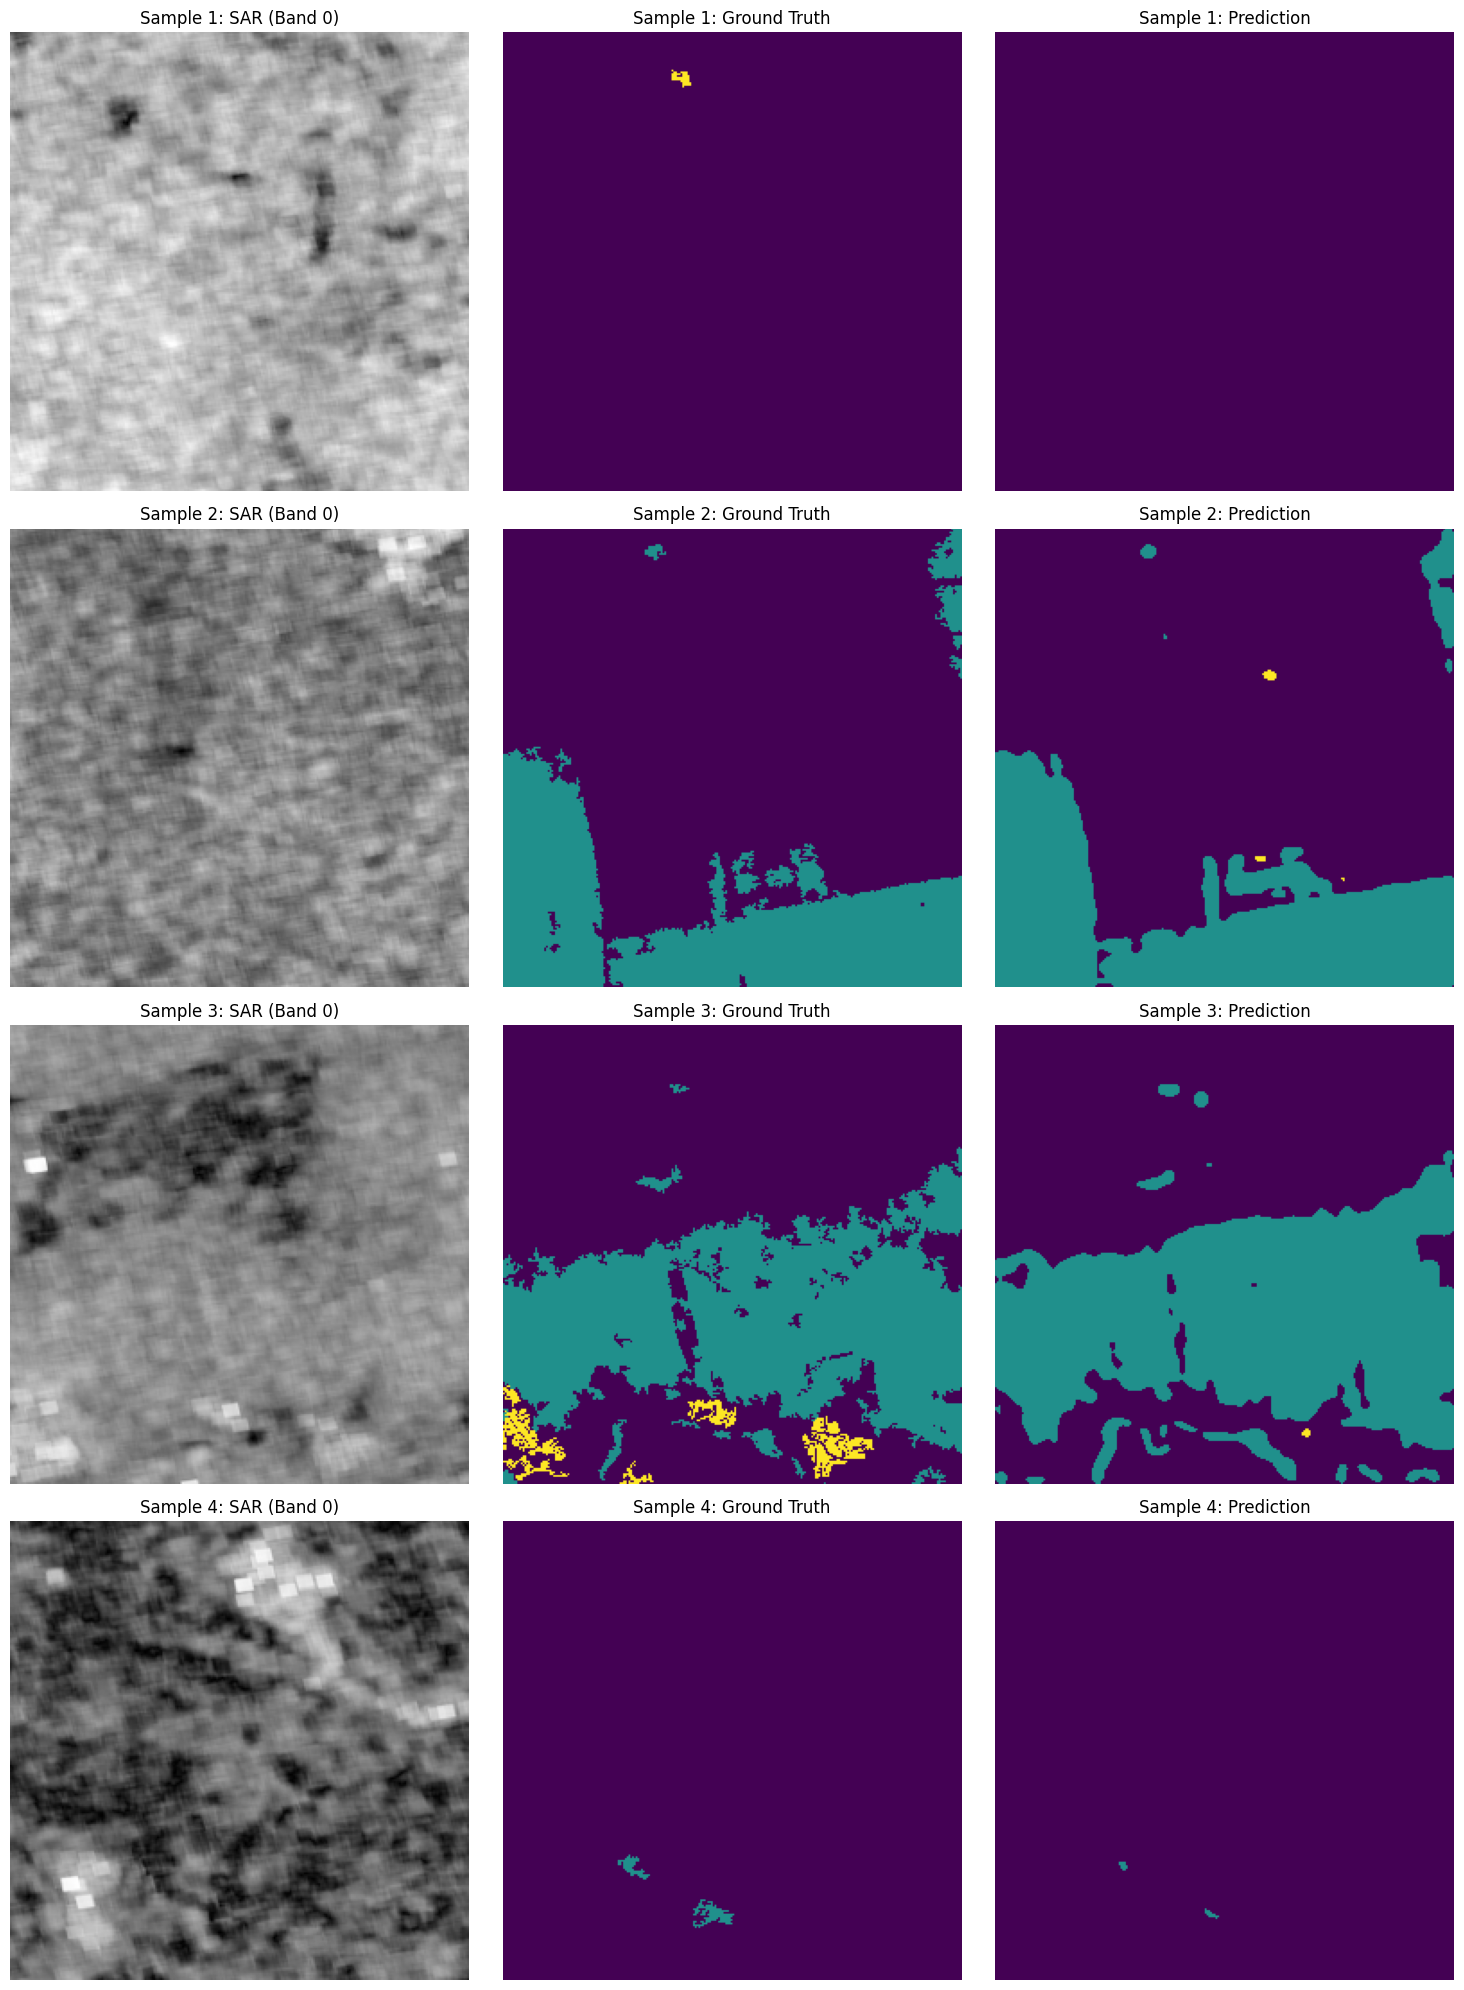

In [10]:
model.load_state_dict(torch.load("unet_resnet50_best.pth"))
model.eval()

val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast("cuda"):
            raw_preds = model(val_images)
    else:
        raw_preds = model(val_images)
pred_masks = torch.argmax(raw_preds, dim=1).cpu().numpy()
val_images_cpu = val_images.cpu().numpy()
val_masks_cpu = val_masks.cpu().numpy()

num_samples = min(4, batch_size)
fig, axes = plt.subplots(num_samples, 3, figsize=(15,5*num_samples))

for i in range(num_samples):
    axes[i, 0].imshow(val_images_cpu[i, 0], cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1}: SAR (Band 0)")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(val_masks_cpu[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(pred_masks[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 2].set_title(f"Sample {i+1}: Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()

## <span style="color:#3498DB;">Results & Visualization</span>

After training, we load the best model and visualise predictions on 4 validation samples. For each sample:

- **Left**: SAR image (first channel)  
- **Middle**: Ground truth mask (0: Non‑Flooded, 1: Flooded Open, 2: Flooded Urban)  
- **Right**: Model prediction

### Observations:
- The model successfully identifies flooded open areas (class 1) with reasonable accuracy.
- **Flooded urban** (class 2) remains challenging due to:
  - Complex backscatter patterns in built‑up areas.
  - Limited training samples (partially mitigated by data augmentation and class weighting).